In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ast

In [4]:
# Read results file into a dataframe
df = pd.read_csv('xyz_extended_resultslog.txt', header=0)
df['top3_y_cands'] = df['top3_y_cands'].apply(lambda x: ast.literal_eval(x))
df['top3_x_cands'] = df['top3_x_cands'].apply(lambda x: ast.literal_eval(x))
df

,num_total_variables,noise_radius,x_to_y_rank,z_to_y_rank,z_to_x_rank,unadjusted,adjusted,top3_y_cands,top3_x_cands
0,10,1,0,1,1,2.000643,0.091253,"[x mean, z mean]","[y mean, z mean]"
1,10,10,0,1,1,2.014766,0.205118,"[x mean, z mean]","[y mean, z mean]"
2,10,100,1,0,0,1.541425,0.031505,"[z mean, x mean]","[z mean, y mean]"
3,100,1,0,1,1,1.999913,0.042731,"[x mean, z mean]","[y mean, z mean]"
4,100,10,0,1,1,1.995647,0.043946,"[x mean, z mean]","[y mean, z mean]"
5,100,100,-1,1,0,0.499038,-0.027073,"[tstamp mean, z mean, var_6 mean]","[z mean, var_15 mean, var_52 mean]"
6,1000,1,0,1,1,1.994315,-0.030422,"[x mean, z mean]","[y mean, z mean]"
7,1000,10,-1,0,0,1.728871,-0.024600,"[z mean, var_738 mean, var_731 mean]","[z mean, var_303 mean, var_337 mean]"
8,1000,100,42,1,1,0.071182,-0.000300,"[tstamp mean, z mean, var_452 mean]","[tstamp mean, z mean, var_675 mean]"


In [5]:
def makeplot(labels:pd.Series, interesting:list, filename:str):

    # Create a 3x3 grid of subplots
    row_labels = df['num_total_variables'].sort_values().unique().tolist()
    col_labels = df['noise_radius'].sort_values().unique().tolist()

    fig, axs = plt.subplots(len(row_labels), len(col_labels), figsize=(10, 10))

    fontsize=20


    # Iterate over each subplot in the grid
    for i, ax in enumerate(axs.flat):
        
        # Create an array of indices for the bars
        indices = np.arange(3)

        # Create an array of colors for the bars
        colors = ["lightgrey"] * min(3, len(labels[i]))
        colors.extend(["white"] * min(3, 3 - len(labels[i])))
        for v in interesting:
            if v in labels[i]:
                colors[labels[i].index(v)] = "#9ACD32"

        # Create the horizontal bars
        l = [1] * 3 
        bars = ax.barh(indices, l, color=colors)
        for j, bar in enumerate(bars):
            if j >= len(labels[i]):    
                bar.set_edgecolor("black")
                bar.set_linestyle("dashed")
                bar.set_linewidth(3)

        # add the text labels
        for j in range(min(3, len(labels[i]))):
            ax.text(
                0.05,
                bars[j].get_y() + bars[j].get_height() / 2,
                labels[i][j],
                ha="left",
                va="center",
                fontsize=fontsize,
            )

        # Invert the y-axis
        ax.invert_yaxis()

        # Set the x-axis range
        ax.set_xlim([0,1])

        # Hide the axis and the outside outline
        ax.get_yaxis().set_visible(False)
        ax.get_xaxis().set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_visible(False)

    # Add row labels on the left side of each row
    for i, label in enumerate(row_labels):
        axs[i, 0].annotate(
            label,
            xy=(0, 0.5),
            xytext=(-20, 0),
            ha="right",
            va="center",
            xycoords="axes fraction",
            textcoords="offset points",
            fontsize=fontsize,
        )

    # Add column labels on the bottom of each column
    for j, label in enumerate(col_labels):
        axs[0, j].annotate(
            label,
            xy=(0.5, -2.9),
            xytext=(0, 10),
            ha="center",
            va="center",
            xycoords="axes fraction",
            textcoords="offset points",
            fontsize=fontsize,
        )

    # Add a horizontal label for the entire plot
    fig.text(0.5, -0.02, 'Noise Radius', ha="center", va="center", fontsize=fontsize)


    # Add a vertical label for the entire plot
    fig.text(
        0, 0.5, 'Num total variables', ha="center", va="center", rotation="vertical", fontsize=fontsize
    )

    # Adjust the spacing between subplots
    plt.subplots_adjust(hspace=0.3, wspace=0.3)
    plt.show

    plt.savefig(filename, bbox_inches='tight')



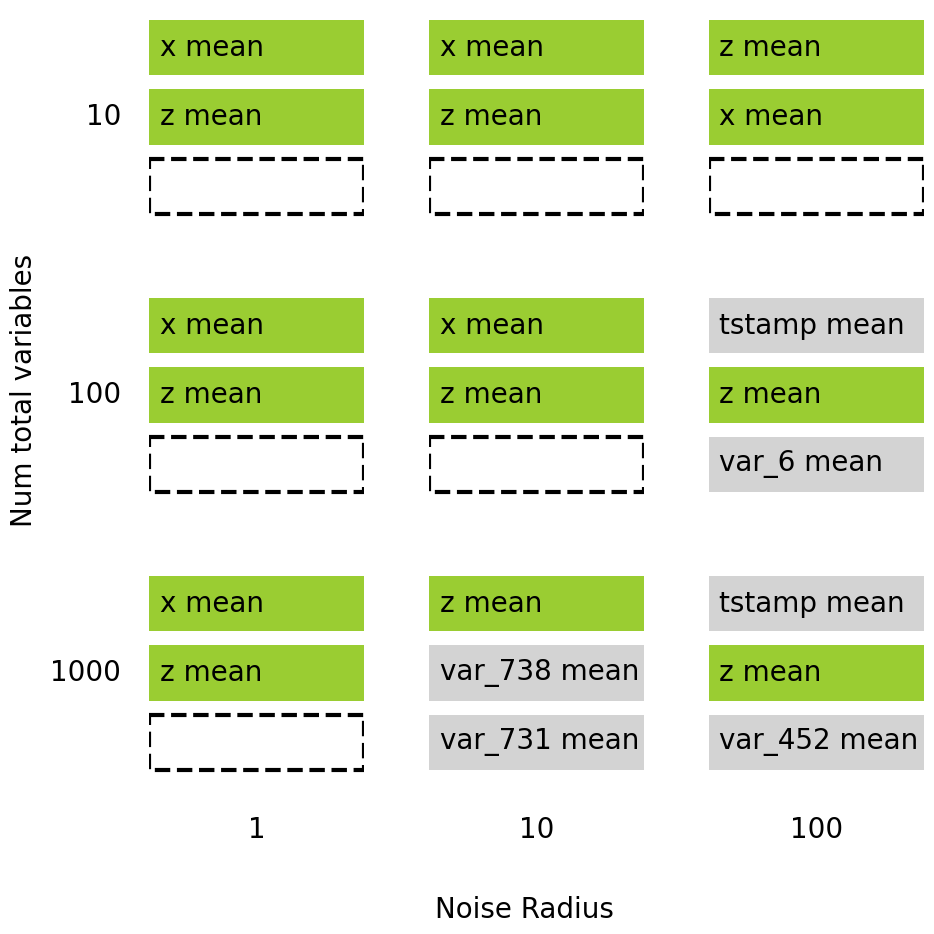

In [6]:
# Causes of y
makeplot(df['top3_y_cands'], ['x mean', 'z mean'], 'xyz_extended_ycauses.png')

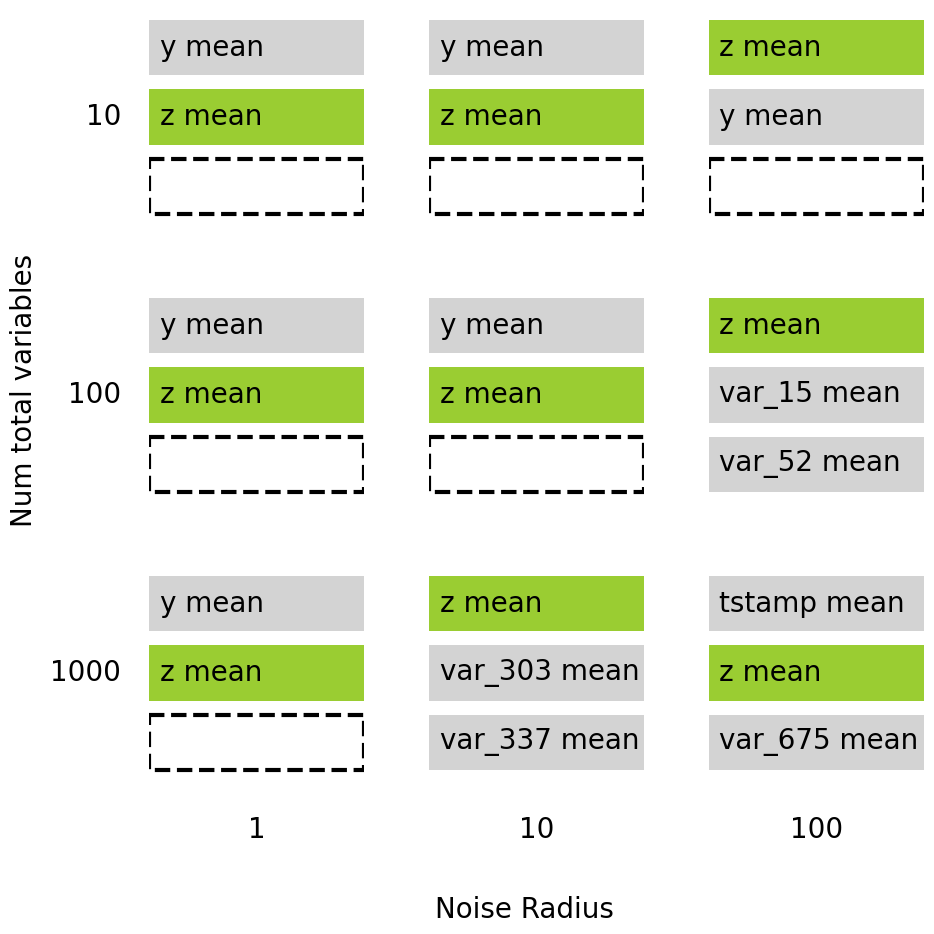

In [7]:
# Causes of x
makeplot(df['top3_x_cands'], ['z mean'], 'xyz_extended_xcauses.png')

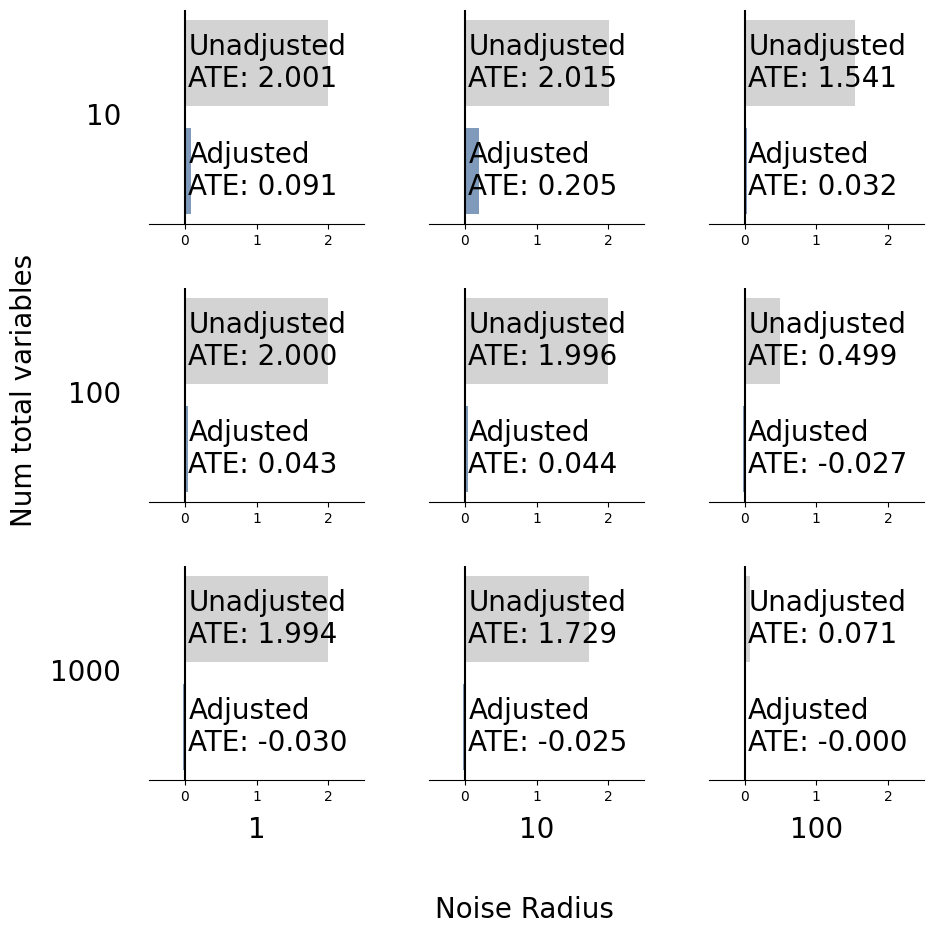

In [8]:
# Plot for the ATEs

# Create a 3x3 grid of subplots
row_labels = df['num_total_variables'].sort_values().unique().tolist()
col_labels = df['noise_radius'].sort_values().unique().tolist()

fig, axs = plt.subplots(len(row_labels), len(col_labels), figsize=(10, 10))

unadjusted = df['unadjusted'].to_list()
adjusted = df['adjusted'].to_list()

fontsize=20


# Iterate over each subplot in the grid
for i, ax in enumerate(axs.flat):


    bars = ax.barh(np.arange(2), [unadjusted[i], adjusted[i]], color=["lightgrey", "#7F9ABA"])

    # Add the text labels
    ax.text(
        0.05,
        bars[0].get_y() + bars[0].get_height() / 2,
        f'Unadjusted\nATE: {unadjusted[i]:.3f}',
        ha="left",
        va="center",
        fontsize=fontsize,
    )
    ax.text(
        0.05,
        bars[1].get_y() + bars[1].get_height() / 2,
        f'Adjusted\nATE: {adjusted[i]:.3f}',
        ha="left",
        va="center",
        fontsize=fontsize,
    )

    # Add a black vertical line at zero
    ax.axvline(0, color="black")

    # Invert the y-axis
    ax.invert_yaxis()

    # Set the x-axis range
    ax.set_xlim([-0.5,2.5])

    # Hide the axis and the outside outline
    ax.get_yaxis().set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Add row labels on the left side of each row
for i, label in enumerate(row_labels):
    axs[i, 0].annotate(
        label,
        xy=(0, 0.5),
        xytext=(-20, 0),
        ha="right",
        va="center",
        xycoords="axes fraction",
        textcoords="offset points",
        fontsize=fontsize,
    )

# Add column labels on the bottom of each column
for j, label in enumerate(col_labels):
    axs[0, j].annotate(
        label,
        xy=(0.5, -2.9),
        xytext=(0, 10),
        ha="center",
        va="center",
        xycoords="axes fraction",
        textcoords="offset points",
        fontsize=fontsize,
    )

# Add a horizontal label for the entire plot
fig.text(0.5, -0.02, 'Noise Radius', ha="center", va="center", fontsize=fontsize)

# Add a vertical label for the entire plot
fig.text(
    0, 0.5, 'Num total variables', ha="center", va="center", rotation="vertical", fontsize=fontsize
)

# Adjust the spacing between subplots
plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show

plt.savefig('xyz_extended_ates.png', bbox_inches='tight')



In [9]:
import pandas as pd
s = pd.Series(
[['Remove (z, x) ', 'Remove (z, y) ', 'Reverse (z, x) '],
['Remove (z, x) ', 'Remove (z, y) ', 'Reverse (z, x) '],
['Remove (z, y) ', 'Reverse (z, x) ', 'Remove (z, x) '],
['Remove (z, x) ', 'Remove (z, y) ', 'Reverse (z, x) '],
['Remove (z, y) ', 'Reverse (z, x) ', 'Remove (z, x) '],
['Remove (z, y) ', 'Reverse (z, x) ', 'Remove (z, x) '],
['Remove (z, y) ', 'Reverse (z, x) ', 'Remove (z, x) '],
['Remove (z, y) ', 'Reverse (z, x) ', 'Remove (z, x) '],
['Remove (z, y) ', 'Reverse (z, x) ', 'Remove (z, x) ']])

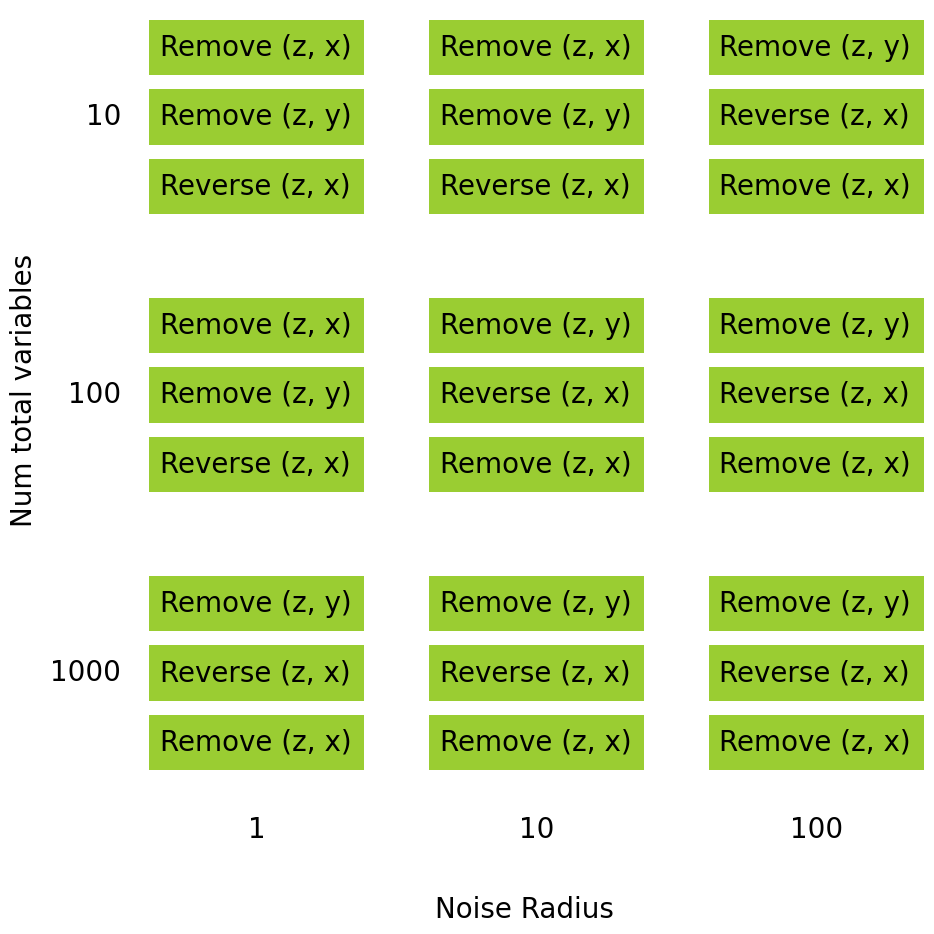

In [10]:
makeplot(s, ['Remove (z, x) ', 'Remove (z, y) ', 'Reverse (z, x) '], 'xyz_extended_challenges.png')